# Jigsaw Unintended Bias — Audit Analysis Notebook
### Ian Tang and Nick Chen (Group #21) — DS-UA 202, Spring 2026

Self-contained Colab notebook implementing the audit analysis described in
`next_steps.md`. Loads pre-trained BERT and LSTM checkpoints from the training
notebook (`DRIVE_DATA_DIR / 'output'`) and produces:

- **Pillar 1** — Per-identity Subgroup / BPSN / BNSP AUCs (§11)
- **Pillar 3** — Module 1 fairness metrics + visualizations (§12-13)
- **Pillar 2** — Counterfactual identity perturbation across all 7 multi-task heads (§14)
- **Pillar 4** — Numerical support for the metric-design critique (§15)

All tables (.csv) and figures (.pdf) are saved to `DRIVE_DATA_DIR / 'audit_outputs'`
for direct inclusion in the LaTeX report. **No retraining required.**


## 1. Environment

In [1]:
#@markdown install bert pretrained
!pip install -q pytorch-pretrained-bert==0.6.2 optuna==3.6.1

In [2]:
#@markdown various imports and env checks
import os, random, re, string, warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
from tqdm.auto import tqdm

import torch
from torch import nn
import torch.nn.functional as F

warnings.filterwarnings('ignore')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


## 2. Mount Drive & Paths

In [3]:
#@markdown mount to google drives and retrieve data to runtime
from google.colab import drive
drive.mount('/content/drive')

DRIVE_DATA_DIR = Path('/content/drive/MyDrive/jigsaw-data')
CKPT_DIR       = DRIVE_DATA_DIR / 'output'
DATA_DIR       = Path('/content/data')
DATA_DIR.mkdir(exist_ok=True)

TRAIN_PATH = DATA_DIR / 'train.csv'
TEST_PATH  = DATA_DIR / 'test.csv'

# Copy data from Drive (needed for LSTM vocab rebuild)
!cp "{DRIVE_DATA_DIR}/train.csv" "{TRAIN_PATH}"
!cp "{DRIVE_DATA_DIR}/test.csv"  "{TEST_PATH}"

assert CKPT_DIR.exists(), f'Checkpoint dir not found: {CKPT_DIR}'
print('Available checkpoints:', list(CKPT_DIR.glob('*.pt')))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Available checkpoints: [PosixPath('/content/drive/MyDrive/jigsaw-data/output/bert_large_uncased.pt'), PosixPath('/content/drive/MyDrive/jigsaw-data/output/lstm_fold0.pt'), PosixPath('/content/drive/MyDrive/jigsaw-data/output/lstm_fold1.pt'), PosixPath('/content/drive/MyDrive/jigsaw-data/output/lstm_fold2.pt'), PosixPath('/content/drive/MyDrive/jigsaw-data/output/lstm_fold3.pt'), PosixPath('/content/drive/MyDrive/jigsaw-data/output/lstm_fold4.pt')]


## 3. Constants

In [4]:
TOXICITY_COLUMN    = 'target'
IDENTITY_COLUMNS   = [
    'male', 'female', 'homosexual_gay_or_lesbian', 'christian', 'jewish',
    'muslim', 'black', 'white', 'psychiatric_or_mental_illness'
]
AUX_TOXICITY_COLUMNS = [
    'severe_toxicity', 'obscene', 'identity_attack',
    'insult', 'threat', 'sexual_explicit'
]
SUBTYPE_COLS = ['toxicity'] + AUX_TOXICITY_COLUMNS  # all 7 output heads

def seed_everything(seed=1234):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

seed_everything(1234)

## 4. Dataset & DataLoader
Minimal versions — inference only, no targets needed.

In [5]:
#@markdown
class TextDataset(torch.utils.data.Dataset):

    def __init__(self, token_lists, targets=None, identities=None, annotator_counts=None):
        self.token_lists      = token_lists
        self.targets          = targets
        self.identities       = identities
        self.annotator_counts = annotator_counts

    def __len__(self):
        return len(self.token_lists)

    def __getitem__(self, idx):
        if self.targets is None:
            return self.token_lists[idx], idx
        return (self.token_lists[idx], idx,
                self.annotator_counts[idx],
                self.targets[idx],
                self.identities[idx])

    def collate_fn(self, batch):
        transposed = list(zip(*batch))
        max_len = max(len(x) for x in transposed[0])
        tokens = np.zeros((len(batch), max_len), dtype=np.int64)
        for i, row in enumerate(transposed[0]):
            tokens[i, :len(row)] = np.array(row[:max_len])
        tensors = [
            torch.from_numpy(tokens),
            torch.tensor(transposed[1], dtype=torch.int32),
        ]
        for i in range(2, len(transposed)):
            tensors.append(torch.tensor(transposed[i], dtype=torch.float32))
        return tensors


class LengthBucketingDataLoader:
    def __init__(self, dataset, batch_size=16, shuffle=False, drop_last=False):
        self.dataset    = dataset
        self.batch_size = batch_size
        self.shuffle    = shuffle
        self.drop_last  = drop_last

    def __iter__(self):
        indices = list(range(len(self.dataset)))
        if self.shuffle:
            random.shuffle(indices)
        bucket = self.batch_size * 100
        batches = []
        for start in range(0, len(indices), bucket):
            chunk = indices[start:start + bucket]
            chunk.sort(key=lambda i: len(self.dataset.token_lists[i]))
            for b_start in range(0, len(chunk), self.batch_size):
                b = chunk[b_start:b_start + self.batch_size]
                if len(b) == self.batch_size or not self.drop_last:
                    batches.append(b)
        if self.shuffle:
            random.shuffle(batches)
        for batch_idx in batches:
            items = [self.dataset[i] for i in batch_idx]
            yield self.dataset.collate_fn(items)

    def __len__(self):
        return len(self.dataset) // self.batch_size

## 5. BERT — Tokenizer & Model Load
Loads `bert-large-uncased` architecture, then overwrites weights from checkpoint.

In [6]:
#@markdown
from pytorch_pretrained_bert import BertTokenizer, BertForSequenceClassification

class HeadTailTokenizer:
    def __init__(self, bert_tokenizer, max_len=220, max_head_len=128):
        self.tok          = bert_tokenizer
        self.max_len      = max_len - 2
        self.max_head_len = max_head_len

    def encode(self, text: str):
        tokens = self.tok.tokenize(str(text))
        if len(tokens) > self.max_len:
            head = tokens[:self.max_head_len]
            tail = tokens[self.max_head_len - self.max_len:]
            tokens = head + tail
        tokens = ['[CLS]'] + tokens + ['[SEP]']
        return self.tok.convert_tokens_to_ids(tokens)

# Build tokenizer
bert_tokenizer = BertTokenizer.from_pretrained('bert-large-uncased', do_lower_case=True)
tokenizer = HeadTailTokenizer(bert_tokenizer, max_len=220, max_head_len=128)

# Load model architecture + checkpoint
bert_model = BertForSequenceClassification.from_pretrained(
    'bert-large-uncased',
    num_labels=1 + len(AUX_TOXICITY_COLUMNS)   # 7 heads
).to(DEVICE)

bert_model.load_state_dict(
    torch.load(CKPT_DIR / 'bert_large_uncased.pt', map_location=DEVICE))
bert_model.eval()
print('BERT checkpoint loaded.')

BERT checkpoint loaded.


## 6. LSTM — Vocab, Embeddings & Model Load
Rebuilds vocab from `train.csv` and loads GloVe/FastText embeddings.
This is the main startup cost (~5 min for embedding download + vocab build).

**TODO for optimization:** Save `token2id` and embedding matrices to Drive during
training so this step becomes a single file load.

In [7]:
# ── Text preprocessing (must match training) ─────────────────────────────────
MISSPELLINGS = {
    "aren't":"are not","can't":"cannot","couldn't":"could not","didn't":"did not",
    "doesn't":"does not","don't":"do not","hadn't":"had not","hasn't":"has not",
    "haven't":"have not","he'd":"he would","he'll":"he will","he's":"he is",
    "i'd":"I had","i'll":"I will","i'm":"I am","isn't":"is not","it's":"it is",
    "it'll":"it will","i've":"I have","let's":"let us","mightn't":"might not",
    "mustn't":"must not","shan't":"shall not","she'd":"she would","she'll":"she will",
    "she's":"she is","shouldn't":"should not","that's":"that is","there's":"there is",
    "they'd":"they would","they'll":"they will","they're":"they are","they've":"they have",
    "we'd":"we would","we're":"we are","weren't":"were not","we've":"we have",
    "what'll":"what will","what're":"what are","what's":"what is","what've":"what have",
    "where's":"where is","who'd":"who would","who'll":"who will","who're":"who are",
    "who's":"who is","who've":"who have","won't":"will not","wouldn't":"would not",
    "you'd":"you would","you'll":"you will","you're":"you are","you've":"you have",
    "'re":" are","wasn't":"was not","we'll":" will","tryin'":"trying",
}
MISSPELL_RE = re.compile('(%s)' % '|'.join(MISSPELLINGS.keys()))

def preprocess_text(text):
    text = str(text).lower()
    text = MISSPELL_RE.sub(lambda m: MISSPELLINGS[m.group(0)], text)
    for p in string.punctuation:
        if p in text:
            text = text.replace(p, f' {p} ')
    text = re.sub(r'\d+', ' ', text)
    return text.strip()

def build_vocab(texts, max_features=100_000):
    counter = Counter()
    for t in texts:
        counter.update(t.split())
    token2id = {'<PAD>': 0, '<UNK>': max_features + 1}
    token2id.update({tok: i + 1 for i, (tok, _) in
                     enumerate(counter.most_common(max_features))})
    return token2id

def tokenize_texts(texts, token2id, max_len=220):
    unk = len(token2id) - 1
    return [[token2id.get(t, unk) for t in txt.split()[:max_len]] for txt in texts]

In [8]:
#@markdown
# ── Rebuild vocab from training text ──────────────────────────────────────────
seed_everything(1029)  # same seed as LSTM training
df_lstm = pd.read_csv(TRAIN_PATH).sample(frac=1, random_state=1029).reset_index(drop=True)
valid_size = 200_000
df_tr_lstm = df_lstm.head(len(df_lstm) - valid_size)

texts_tr = df_tr_lstm['comment_text'].astype(str).apply(preprocess_text).tolist()
token2id = build_vocab(texts_tr, max_features=100_000)
print(f'Vocab size: {len(token2id):,}')

del df_lstm, df_tr_lstm, texts_tr  # free memory

Vocab size: 100,002


In [9]:
#@markdown
#── Load embeddings ───────────────────────────────────────────────────────────
GLOVE_PATH    = Path('/content/glove.840B.300d.txt')
FASTTEXT_PATH = Path('/content/crawl-300d-2M.vec')

if not GLOVE_PATH.exists():
    print("Downloading GloVe 840B 300d...")
    !wget -q --show-progress "https://nlp.stanford.edu/data/glove.840B.300d.zip" -O /tmp/glove.zip
    !unzip -q /tmp/glove.zip -d /content/

if not FASTTEXT_PATH.exists():
    print("Downloading FastText crawl-300d-2M...")
    !wget -q --show-progress "https://dl.fbaipublicfiles.com/fasttext/vectors-english/crawl-300d-2M.vec.zip" -O /tmp/ft.zip
    !unzip -q /tmp/ft.zip -d /content/

def load_embedding_matrix(path, token2id, embed_size=300):
    index = {}
    with open(path, encoding='utf-8', errors='ignore') as f:
        for line in tqdm(f, desc=f'Loading {Path(path).name}'):
            parts = line.rstrip().split(' ')
            if len(parts) == embed_size + 1:
                index[parts[0]] = np.array(parts[1:], dtype=np.float32)
    nb_words = min(len(token2id), max(token2id.values()) + 1)
    matrix   = np.zeros((nb_words, embed_size), dtype=np.float32)
    for word, i in token2id.items():
        if i >= nb_words:
            continue
        for candidate in [word, word.lower(), word.upper(), word.capitalize()]:
          if candidate in index:
              matrix[i] = index[candidate]
              break
    return matrix

glove_matrix    = load_embedding_matrix(GLOVE_PATH,    token2id)
fasttext_matrix = load_embedding_matrix(FASTTEXT_PATH, token2id)
print(f'Embedding matrices: {glove_matrix.shape}, {fasttext_matrix.shape}')

/tmp/glove.zip      100%[===================>]   2.03G  4.98MB/s    in 6m 50s  
/tmp/ft.zip         100%[===================>]   1.42G  26.6MB/s    in 55s     


Loading glove.840B.300d.txt: 0it [00:00, ?it/s]

Loading crawl-300d-2M.vec: 0it [00:00, ?it/s]

Embedding matrices: (100002, 300), (100002, 300)


In [10]:
#@markdown
# ── LSTM architecture ─────────────────────────────────────────────────────────
class SpatialDropout(nn.Dropout2d):
    def forward(self, x):
        x = x.unsqueeze(2).permute(0, 3, 2, 1)
        x = super().forward(x)
        return x.permute(0, 3, 2, 1).squeeze(2)

class ProjSumEmbedding(nn.Module):
    def __init__(self, matrices, output_size):
        super().__init__()
        self.projectors = nn.ModuleList()
        for m in matrices:
            emb = nn.Embedding(*m.shape)
            emb.weight = nn.Parameter(torch.tensor(m, dtype=torch.float32))
            emb.weight.requires_grad = False
            proj = nn.Linear(m.shape[1], output_size)
            nn.init.xavier_uniform_(proj.weight)
            self.projectors.append(nn.Sequential(emb, proj))

    def forward(self, x):
        return F.relu(sum(p(x) for p in self.projectors))

class LstmGruNet(nn.Module):
    def __init__(self, embedding_matrices, num_aux_targets,
                 embed_proj_size=256, lstm_units=128, gru_units=128):
        super().__init__()
        self.embedding         = ProjSumEmbedding(embedding_matrices, embed_proj_size)
        self.embedding_dropout = SpatialDropout(0.2)
        self.lstm = nn.LSTM(embed_proj_size, lstm_units, bidirectional=True, batch_first=True)
        self.gru  = nn.GRU(lstm_units * 2, gru_units, bidirectional=True, batch_first=True)
        dense_in  = gru_units * 4
        self.fc1  = nn.Linear(dense_in, dense_in)
        self.fc2  = nn.Linear(dense_in, dense_in)
        self.out_main = nn.Linear(dense_in, 1)
        self.out_aux  = nn.Linear(dense_in, num_aux_targets)

    def forward(self, x):
        h = self.embedding_dropout(self.embedding(x))
        h, _ = self.lstm(h)
        h, _ = self.gru(h)
        avg_pool = h.mean(dim=1)
        max_pool = h.max(dim=1).values
        h = torch.cat([avg_pool, max_pool], dim=1)
        h = h + F.relu(self.fc1(h)) + F.relu(self.fc2(h))
        return torch.cat([self.out_main(h), self.out_aux(h)], dim=1)

# ── Load all 5 fold checkpoints ──────────────────────────────────────────────
NUM_FOLDS = 5
lstm_models = []
for fold in range(NUM_FOLDS):
    m = LstmGruNet(
        embedding_matrices=[glove_matrix, fasttext_matrix],
        num_aux_targets=len(AUX_TOXICITY_COLUMNS),
    ).to(DEVICE)
    m.load_state_dict(torch.load(CKPT_DIR / f'lstm_fold{fold}.pt', map_location=DEVICE))
    m.eval()
    lstm_models.append(m)

print(f'Loaded {len(lstm_models)} LSTM fold checkpoints.')

Loaded 5 LSTM fold checkpoints.


## 7. Multi-Head Inference Functions

In [11]:
#@markdown Return all 7 output heads: `[toxicity, severe_toxicity, obscene, identity_attack, insult, threat, sexual_explicit]`
def predict_bert_multitask(model, token_lists, batch_size=8, device=DEVICE):
    """Returns (N, 7) array — all output heads after sigmoid."""
    model.eval()
    ds = TextDataset(token_lists)
    loader = LengthBucketingDataLoader(ds, batch_size=batch_size, shuffle=False)
    all_preds, all_idx = [], []
    with torch.no_grad():
        for x, idx in loader:
            with torch.cuda.amp.autocast():
                logits = model(x.to(device), attention_mask=(x.to(device) > 0), labels=None)
            all_preds.append(torch.sigmoid(logits).cpu().numpy())
            all_idx.append(idx.numpy())
    preds = np.concatenate(all_preds)
    idx   = np.concatenate(all_idx)
    return preds[np.argsort(idx)]


def predict_lstm_multitask(models, sentences, token2id, max_len=220, batch_size=64, device=DEVICE):
    """Preprocess → tokenize → average across fold models. Returns (N, 7)."""
    processed = [preprocess_text(s) for s in sentences]
    seqs = tokenize_texts(processed, token2id, max_len)
    ds = TextDataset(seqs)
    loader = LengthBucketingDataLoader(ds, batch_size=batch_size, shuffle=False)

    fold_preds = []
    for model in models:
        model.eval()
        preds, idxs = [], []
        with torch.no_grad():
            for x, idx in loader:
                logits = model(x.long().to(device))
                preds.append(torch.sigmoid(logits).cpu().numpy())
                idxs.append(idx.numpy())
        p = np.concatenate(preds)
        i = np.concatenate(idxs)
        fold_preds.append(p[np.argsort(i)])

    return np.mean(fold_preds, axis=0)


def predict_ensemble_multitask(sentences, bert_model, tokenizer,
                                lstm_models, token2id, blend_weights,
                                device=DEVICE):
    """Full ensemble: BERT + LSTM blended. Returns (N, 7)."""
    toks = [tokenizer.encode(s) for s in sentences]
    bert_preds = predict_bert_multitask(bert_model, toks, device=device)
    lstm_preds = predict_lstm_multitask(lstm_models, sentences, token2id, device=device)

    bert_w = blend_weights.get('bert_large_uncased', 0.5)
    lstm_w = blend_weights.get('lstm_gru', 0.5)
    return bert_preds * bert_w + lstm_preds * lstm_w, bert_preds, lstm_preds

## 8. Blend Weights
Hardcode from Optuna results in the training notebook.
Update these values if you re-run blending.

In [12]:
# From training notebook Optuna output — update if re-blended
blend_weights = {
    'bert_large_uncased': 0.993,
    'lstm_gru':           0.007,
}
print('Blend weights:', blend_weights)

Blend weights: {'bert_large_uncased': 0.993, 'lstm_gru': 0.007}


## 9. Quick Test

In [18]:
#@markdown Quick check that all heads produce plausible outputs before running the full analysis.
test_sentences = [
    "I am a Muslim.",
    "I am a Christian",
    "I hate all Christians.",
    "The weather is nice today.",
    "The weather is bad, and I am a human."
]

ensemble_preds, bert_preds, lstm_preds = predict_ensemble_multitask(
    test_sentences, bert_model, tokenizer,
    lstm_models, token2id, blend_weights)

pd.set_option('display.float_format', '{:.4f}'.format)
print('BERT multi-head outputs:')
display(pd.DataFrame(bert_preds, columns=SUBTYPE_COLS, index=test_sentences))
print()
print('LSTM multi-head outputs (fold-averaged):')
display(pd.DataFrame(lstm_preds, columns=SUBTYPE_COLS, index=test_sentences))
print()
print('Ensemble multi-head outputs:')
display(pd.DataFrame(ensemble_preds, columns=SUBTYPE_COLS, index=test_sentences))

BERT multi-head outputs:


,toxicity,severe_toxicity,obscene,identity_attack,insult,threat,sexual_explicit
I am a Muslim.,0.0199,0.0011,0.0013,0.0246,0.0047,0.0011,0.0011
I am a Christian,0.0095,0.0008,0.0012,0.0092,0.0026,0.0009,0.0010
I hate all Christians.,0.8882,0.1372,0.0461,0.9180,0.6167,0.0389,0.0123
The weather is nice today.,0.0030,0.0009,0.0013,0.0016,0.0019,0.0013,0.0010
"The weather is bad, and I am a human.",0.0142,0.0008,0.0019,0.0021,0.0110,0.0010,0.0008



LSTM multi-head outputs (fold-averaged):


,toxicity,severe_toxicity,obscene,identity_attack,insult,threat,sexual_explicit
I am a Muslim.,0.1599,0.0205,0.0143,0.1992,0.0555,0.0142,0.0121
I am a Christian,0.0875,0.0194,0.0182,0.0911,0.0437,0.0147,0.0160
I hate all Christians.,0.2820,0.0245,0.0240,0.0408,0.1229,0.0613,0.0139
The weather is nice today.,0.0401,0.0199,0.0222,0.0242,0.0324,0.0206,0.0214
"The weather is bad, and I am a human.",0.1412,0.0178,0.0192,0.0311,0.1094,0.0183,0.0157



Ensemble multi-head outputs:


,toxicity,severe_toxicity,obscene,identity_attack,insult,threat,sexual_explicit
I am a Muslim.,0.0208,0.0013,0.0014,0.0258,0.0051,0.0011,0.0012
I am a Christian,0.0101,0.0009,0.0013,0.0098,0.0029,0.0010,0.0011
I hate all Christians.,0.8843,0.1364,0.0460,0.9119,0.6132,0.0391,0.0124
The weather is nice today.,0.0033,0.0010,0.0015,0.0017,0.0021,0.0014,0.0012
"The weather is bad, and I am a human.",0.0151,0.0009,0.0020,0.0023,0.0117,0.0011,0.0009


## 10. Audit Setup & Validation Predictions
We evaluate on the official Civil Comments private leaderboard split
(`test_private_expanded.csv`), which carries both toxicity and identity labels.
Predictions for all three model variants (BERT, LSTM, ensemble) are cached
to Drive on first run; subsequent runs load from cache.


In [19]:
#@markdown Copy the private test set from Drive if needed and load it.
PRIV_PATH = DATA_DIR / 'test_private_expanded.csv'
if not PRIV_PATH.exists():
    src = DRIVE_DATA_DIR / 'test_private_expanded.csv'
    assert src.exists(), f'Missing private test set at {src}'
    !cp "{src}" "{PRIV_PATH}"

df_priv = pd.read_csv(PRIV_PATH).fillna(0)
print(f'Private test samples: {len(df_priv):,}')


Private test samples: 97,320


In [20]:
#@markdown Run (or load cached) ensemble predictions on the private test set.
PRED_CACHE = CKPT_DIR / 'audit_preds_priv.npz'

if PRED_CACHE.exists():
    cache = np.load(PRED_CACHE)
    bert_preds_priv = cache['bert']
    lstm_preds_priv = cache['lstm']
    ens_preds_priv  = cache['ensemble']
    print(f'Loaded cached predictions: shape {ens_preds_priv.shape}')
else:
    sentences = df_priv['comment_text'].astype(str).tolist()
    ens_preds_priv, bert_preds_priv, lstm_preds_priv = predict_ensemble_multitask(
        sentences, bert_model, tokenizer,
        lstm_models, token2id, blend_weights)
    np.savez_compressed(PRED_CACHE,
        bert=bert_preds_priv, lstm=lstm_preds_priv, ensemble=ens_preds_priv)
    print(f'Computed and cached predictions: shape {ens_preds_priv.shape}')


Computed and cached predictions: shape (97320, 7)


In [21]:
#@markdown Output directories for tables and figures (LaTeX-friendly PDFs).
OUT_DIR   = DRIVE_DATA_DIR / 'audit_outputs'
TABLE_DIR = OUT_DIR / 'tables'
FIG_DIR   = OUT_DIR / 'figures'
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt
plt.rcParams.update({'figure.dpi': 110, 'savefig.bbox': 'tight'})


## 11. Pillar 1 — Subgroup Fairness Analysis
Per-identity Subgroup AUC, BPSN AUC, and BNSP AUC across the 9 evaluated
identities. The `JigsawEvaluator` class mirrors the one in the training
notebook so the audit's numbers are directly comparable to the draft report's
0.94466 private-LB score.


In [22]:
#@markdown Competition evaluator: 0.25*overall_AUC + 0.75*mean(power_mean(sub, BPSN, BNSP)).
from sklearn.metrics import roc_auc_score

class JigsawEvaluator:
    def __init__(self, y_true, y_identity, power=-5, overall_weight=0.25):
        self.y    = (y_true >= 0.5).astype(int)
        self.y_i  = (y_identity >= 0.5).astype(int)
        self.n    = self.y_i.shape[1]
        self.power = power
        self.overall_weight = overall_weight

    @staticmethod
    def _auc(y, p):
        try:    return roc_auc_score(y, p)
        except ValueError: return 1e-15

    def _subgroup_auc(self, i, p):
        m = self.y_i[:, i] == 1
        return self._auc(self.y[m], p[m])

    def _bpsn_auc(self, i, p):
        m = self.y_i[:, i] + self.y == 1
        return self._auc(self.y[m], p[m])

    def _bnsp_auc(self, i, p):
        m = self.y_i[:, i] + self.y != 1
        return self._auc(self.y[m], p[m])

    def _power_mean(self, arr):
        return np.power(np.mean(np.power(arr, self.power)), 1 / self.power)

    def get_score(self, y_pred):
        sub  = np.array([self._subgroup_auc(i, y_pred) for i in range(self.n)])
        bpsn = np.array([self._bpsn_auc(i, y_pred)     for i in range(self.n)])
        bnsp = np.array([self._bnsp_auc(i, y_pred)     for i in range(self.n)])
        bias = np.mean([self._power_mean(sub),
                        self._power_mean(bpsn),
                        self._power_mean(bnsp)])
        overall = roc_auc_score(self.y, y_pred)
        final   = self.overall_weight * overall + (1 - self.overall_weight) * bias
        return final, {
            'overall_auc':       overall,
            'mean_subgroup_auc': self._power_mean(sub),
            'mean_bpsn_auc':     self._power_mean(bpsn),
            'mean_bnsp_auc':     self._power_mean(bnsp),
            'final_score':       final,
            'subgroup_auc': dict(zip(IDENTITY_COLUMNS, sub)),
            'bpsn_auc':     dict(zip(IDENTITY_COLUMNS, bpsn)),
            'bnsp_auc':     dict(zip(IDENTITY_COLUMNS, bnsp)),
        }


In [23]:
#@markdown Compute per-identity bias AUCs and save to CSV.
y_true_priv     = df_priv['toxicity'].values
y_identity_priv = df_priv[IDENTITY_COLUMNS].values
y_pred_priv     = ens_preds_priv[:, 0]   # primary toxicity head

evaluator = JigsawEvaluator(y_true_priv, y_identity_priv)
final, details = evaluator.get_score(y_pred_priv)

print(f'Final competition score : {final:.5f}')
print(f'  Overall AUC           : {details["overall_auc"]:.5f}')
print(f'  Mean Subgroup AUC     : {details["mean_subgroup_auc"]:.5f}')
print(f'  Mean BPSN AUC         : {details["mean_bpsn_auc"]:.5f}')
print(f'  Mean BNSP AUC         : {details["mean_bnsp_auc"]:.5f}')

bias_table = pd.DataFrame({
    'identity':     IDENTITY_COLUMNS,
    'subgroup_n':   [int((y_identity_priv[:, i] >= 0.5).sum())
                     for i in range(len(IDENTITY_COLUMNS))],
    'subgroup_auc': [details['subgroup_auc'][i] for i in IDENTITY_COLUMNS],
    'bpsn_auc':     [details['bpsn_auc'][i]     for i in IDENTITY_COLUMNS],
    'bnsp_auc':     [details['bnsp_auc'][i]     for i in IDENTITY_COLUMNS],
})
bias_table.to_csv(TABLE_DIR / 'bias_aucs_per_identity.csv', index=False)
display(bias_table.round(4))


Final competition score : 0.94464
  Overall AUC           : 0.97368
  Mean Subgroup AUC     : 0.90183
  Mean BPSN AUC         : 0.94762
  Mean BNSP AUC         : 0.95544


,identity,subgroup_n,subgroup_auc,bpsn_auc,bnsp_auc
0,male,2112,0.9367,0.9621,0.9592
1,female,2602,0.9418,0.9722,0.9515
2,homosexual_gay_or_lesbian,538,0.8541,0.9298,0.9504
3,christian,2109,0.9475,0.9761,0.9471
4,jewish,411,0.9098,0.9541,0.9518
5,muslim,1054,0.8723,0.9424,0.9489
6,black,761,0.8670,0.9258,0.9573
7,white,1178,0.8738,0.9243,0.9593
8,psychiatric_or_mental_illness,238,0.9560,0.9514,0.9753


## 12. Pillar 3 — Module 1 Fairness Metrics (professor-required)
The competition's AUC-based metric ignores the threshold choice. A deployed
moderation system must binarize. We threshold the toxicity score at $s_{HR}=0.5$
and compute the Module 1 confusion-matrix metrics (Chouldechova) per subgroup:
calibration / predictive parity (PPV), error-rate balance (FPR, FNR),
statistical parity (selection rate), equal opportunity (TPR).

The choice of threshold is itself a normative act. See report §0/§5 for the
stakeholder-driven discussion of why $s_{HR}=0.5$ is a debatable default.


In [24]:
#@markdown Per-subgroup confusion-matrix metrics at threshold s_HR.
S_HR = 0.5
y_bin = (y_true_priv >= 0.5).astype(int)
y_hat = (y_pred_priv >= S_HR).astype(int)

def cm_metrics(y_true, y_pred):
    TP = int(((y_true == 1) & (y_pred == 1)).sum())
    FP = int(((y_true == 0) & (y_pred == 1)).sum())
    FN = int(((y_true == 1) & (y_pred == 0)).sum())
    TN = int(((y_true == 0) & (y_pred == 0)).sum())
    n  = TP + FP + FN + TN
    safe = lambda num, den: (num / den) if den else float('nan')
    return {
        'n':              n,
        'base_rate':      safe(TP + FN, n),
        'selection_rate': safe(TP + FP, n),
        'PPV':            safe(TP, TP + FP),
        'TPR':            safe(TP, TP + FN),
        'FPR':            safe(FP, FP + TN),
        'FNR':            safe(FN, FN + TP),
    }

rows = [{'identity': 'OVERALL', **cm_metrics(y_bin, y_hat)}]
for i, ident in enumerate(IDENTITY_COLUMNS):
    m = y_identity_priv[:, i] >= 0.5
    rows.append({'identity': ident, **cm_metrics(y_bin[m], y_hat[m])})

m1 = pd.DataFrame(rows)
m1.to_csv(TABLE_DIR / 'module1_metrics_per_identity.csv', index=False)
print(f'Threshold s_HR = {S_HR}')
display(m1.round(4))


Threshold s_HR = 0.5


,identity,n,base_rate,selection_rate,PPV,TPR,FPR,FNR
0,OVERALL,97320,0.0799,0.0856,0.6873,0.7363,0.0291,0.2637
1,male,2112,0.1515,0.1061,0.7679,0.5375,0.0290,0.4625
2,female,2602,0.1345,0.0796,0.8406,0.4971,0.0147,0.5029
3,homosexual_gay_or_lesbian,538,0.2862,0.1468,0.7975,0.4091,0.0417,0.5909
4,christian,2109,0.0996,0.0512,0.7870,0.4048,0.0121,0.5952
5,jewish,411,0.1655,0.0998,0.7317,0.4412,0.0321,0.5588
6,muslim,1054,0.2211,0.1195,0.7698,0.4163,0.0353,0.5837
7,black,761,0.3233,0.1840,0.8071,0.4593,0.0524,0.5407
8,white,1178,0.2997,0.1689,0.8040,0.4533,0.0473,0.5467
9,psychiatric_or_mental_illness,238,0.2269,0.2059,0.7755,0.7037,0.0598,0.2963


In [25]:
#@markdown Numerical demonstration of the impossibility result (Chouldechova).
#@markdown With differing per-subgroup base rates, predictive parity (equal PPV)
#@markdown and error-rate balance (equal FPR, FNR) cannot all hold simultaneously
#@markdown unless the model is perfect. We verify the algebraic identity
#@markdown FPR = (p/(1-p)) * ((1-PPV)/PPV) * (1-FNR) per subgroup as the bridge.
print('Per-subgroup base rates P(Y=1 | identity):')
for r in rows[1:]:
    print(f'  {r["identity"]:<35} base_rate={r["base_rate"]:.4f}')
print(f'  {"OVERALL":<35} base_rate={rows[0]["base_rate"]:.4f}')

print('\nChouldechova identity check (derived FPR vs measured FPR):')
for r in rows[1:]:
    p, PPV, FNR, FPR = r['base_rate'], r['PPV'], r['FNR'], r['FPR']
    if not (np.isnan(PPV) or np.isnan(FNR)) and PPV > 0 and (1 - p) > 0:
        derived = (p / (1 - p)) * ((1 - PPV) / PPV) * (1 - FNR)
        print(f'  {r["identity"]:<35} measured={FPR:.4f}  derived={derived:.4f}')


Per-subgroup base rates P(Y=1 | identity):
  male                                base_rate=0.1515
  female                              base_rate=0.1345
  homosexual_gay_or_lesbian           base_rate=0.2862
  christian                           base_rate=0.0996
  jewish                              base_rate=0.1655
  muslim                              base_rate=0.2211
  black                               base_rate=0.3233
  white                               base_rate=0.2997
  psychiatric_or_mental_illness       base_rate=0.2269
  OVERALL                             base_rate=0.0799

Chouldechova identity check (derived FPR vs measured FPR):
  male                                measured=0.0290  derived=0.0290
  female                              measured=0.0147  derived=0.0147
  homosexual_gay_or_lesbian           measured=0.0417  derived=0.0417
  christian                           measured=0.0121  derived=0.0121
  jewish                              measured=0.0321  derived=0.03

## 13. Visualizations
Three figures for the report:
(a) per-identity bias AUC bar chart,
(b) toxicity-score distributions per subgroup (with threshold line),
(c) Module 1 metrics bar chart per identity.
All saved as PDF for direct LaTeX inclusion.


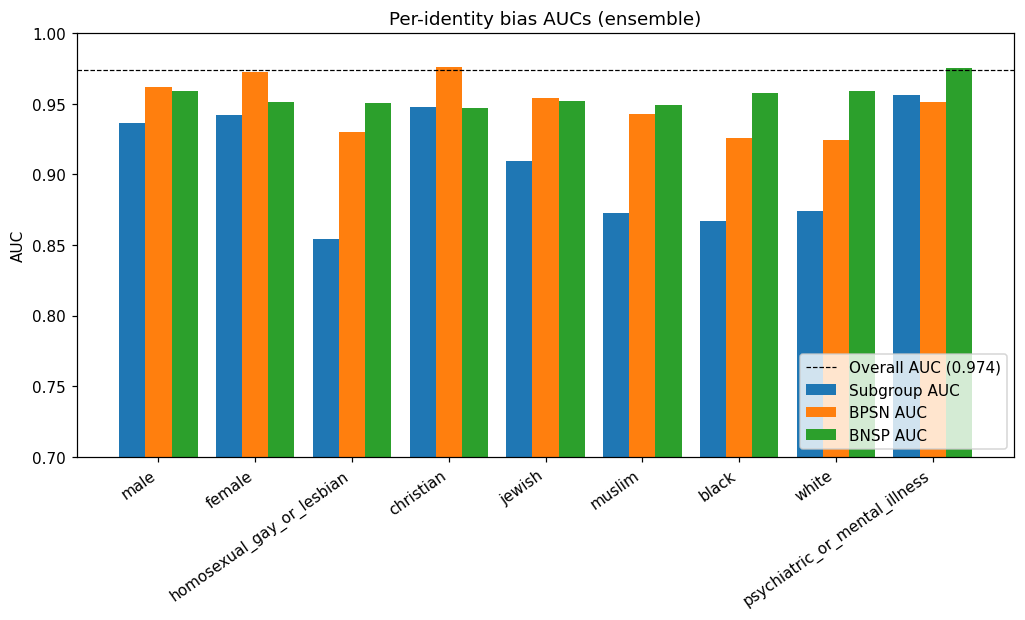

In [26]:
#@markdown (a) Grouped bar chart of the 3 bias AUCs per identity.
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(IDENTITY_COLUMNS)); w = 0.27
ax.bar(x - w, bias_table['subgroup_auc'], width=w, label='Subgroup AUC')
ax.bar(x,     bias_table['bpsn_auc'],     width=w, label='BPSN AUC')
ax.bar(x + w, bias_table['bnsp_auc'],     width=w, label='BNSP AUC')
ax.axhline(details['overall_auc'], color='black', linestyle='--', linewidth=0.8,
           label=f'Overall AUC ({details["overall_auc"]:.3f})')
ax.set_xticks(x)
ax.set_xticklabels(IDENTITY_COLUMNS, rotation=35, ha='right')
ax.set_ylabel('AUC'); ax.set_ylim(0.7, 1.0)
ax.set_title('Per-identity bias AUCs (ensemble)')
ax.legend(loc='lower right')
plt.savefig(FIG_DIR / 'bias_aucs_per_identity.pdf')
plt.show()


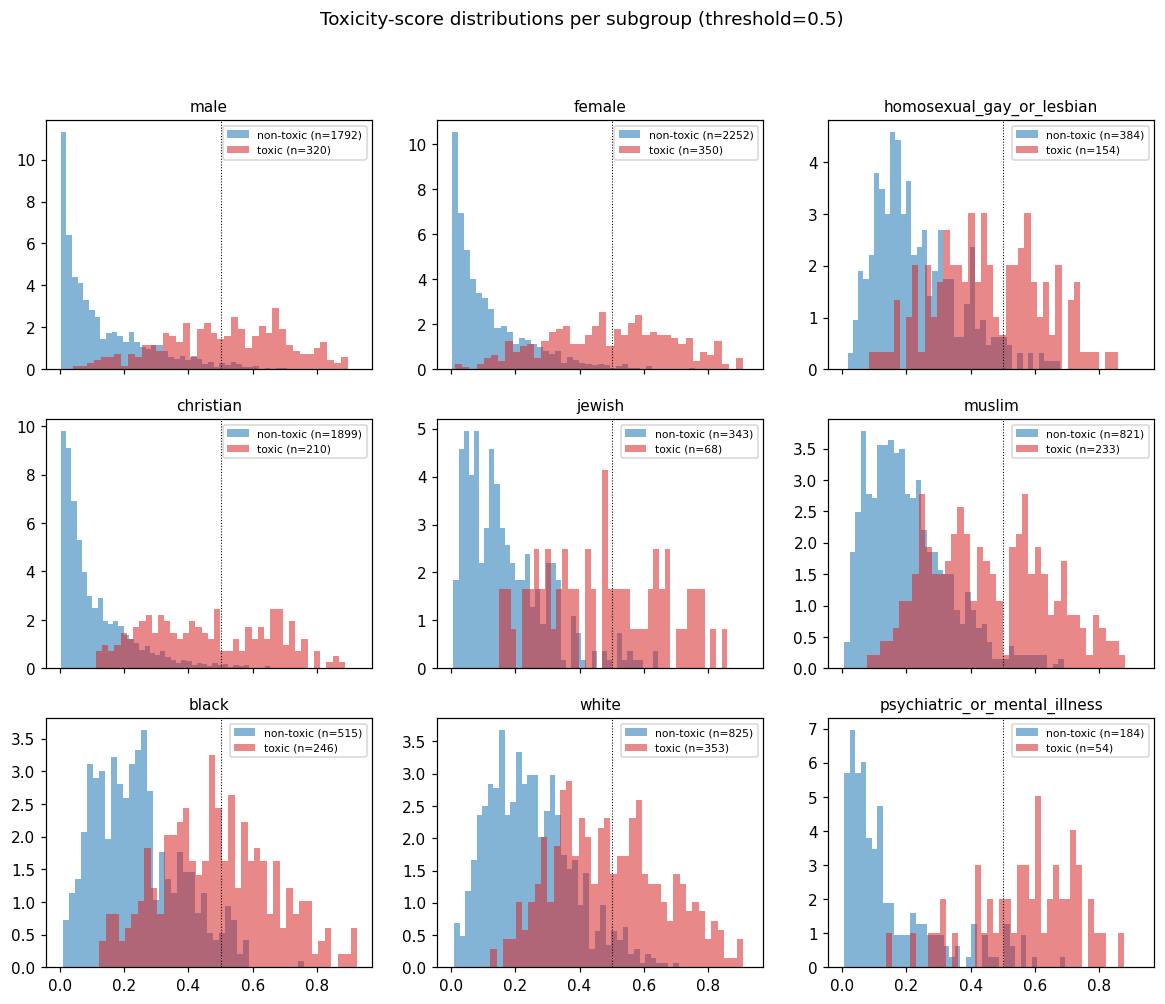

In [27]:
#@markdown (b) Toxicity-score distributions per subgroup, positive vs negative class.
fig, axes = plt.subplots(3, 3, figsize=(13, 10), sharex=True)
for i, (ident, ax) in enumerate(zip(IDENTITY_COLUMNS, axes.flat)):
    m   = y_identity_priv[:, i] >= 0.5
    pos = y_pred_priv[m & (y_bin == 1)]
    neg = y_pred_priv[m & (y_bin == 0)]
    ax.hist(neg, bins=40, alpha=0.55, density=True,
            label=f'non-toxic (n={len(neg)})', color='C0')
    ax.hist(pos, bins=40, alpha=0.55, density=True,
            label=f'toxic (n={len(pos)})', color='C3')
    ax.axvline(S_HR, color='black', linestyle=':', linewidth=0.7)
    ax.set_title(ident, fontsize=10)
    ax.legend(fontsize=7)
fig.suptitle(f'Toxicity-score distributions per subgroup (threshold={S_HR})')
plt.savefig(FIG_DIR / 'score_dist_per_subgroup.pdf')
plt.show()


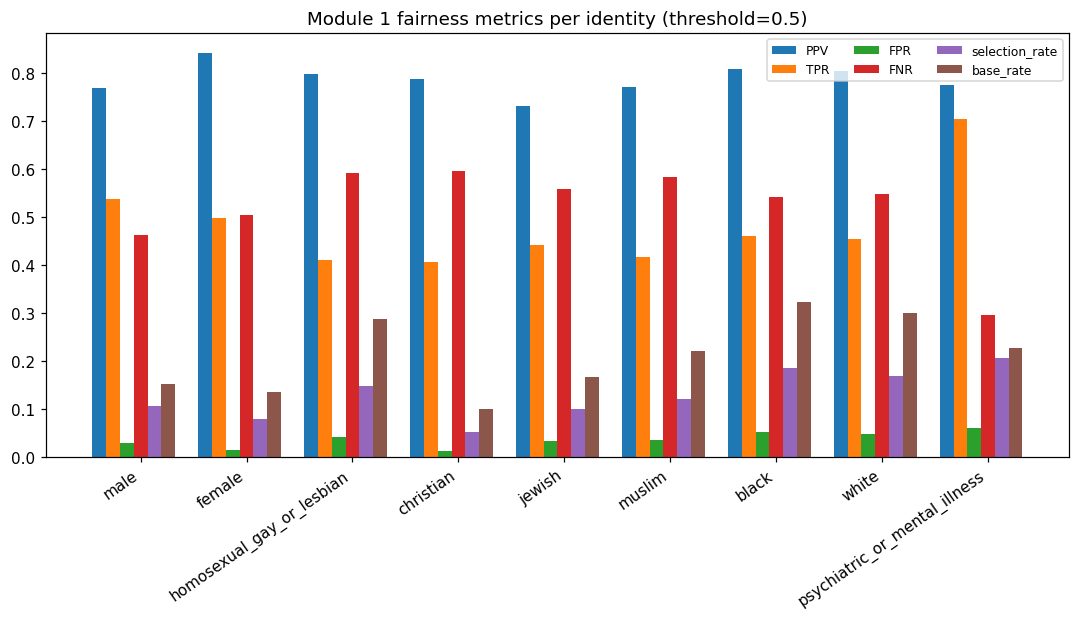

In [28]:
#@markdown (c) Module 1 fairness metrics per identity.
metrics_to_plot = ['PPV', 'TPR', 'FPR', 'FNR', 'selection_rate', 'base_rate']
m1_sub = m1[m1['identity'] != 'OVERALL'].set_index('identity')

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(m1_sub)); w = 0.13
for k, met in enumerate(metrics_to_plot):
    ax.bar(x + (k - len(metrics_to_plot)/2) * w, m1_sub[met], width=w, label=met)
ax.set_xticks(x)
ax.set_xticklabels(m1_sub.index, rotation=35, ha='right')
ax.set_title(f'Module 1 fairness metrics per identity (threshold={S_HR})')
ax.legend(loc='upper right', ncol=3, fontsize=8)
plt.savefig(FIG_DIR / 'module1_metrics_per_identity.pdf')
plt.show()


## 14. Pillar 2 — Counterfactual Identity Perturbation
Template sentences with swapped identity tokens, evaluated across all 7
multi-task heads. Designed per `kaggle_jigsaw/counterfactual_framework_outline.md`
and the professor's notes on causality.


### Causality framing (per professor's notes)

**The DAG.** Standard fairness assumes features $X$ cause label $Y$. Toxicity
classification is **anti-causal**: the comment author's intent $U$ generates the
text $T$, and a human rater's perception of $T$ generates the label $Y$. The
identity mention is *part of $T$*, not a separate confounder. The model learns
$P(Y \mid T)$, but the data-generating process is $U \to T \to Y$ with rater
bias entering at the $T \to Y$ step.

**What "intervention" means here.** Template substitution swaps an identity
token in $T$ while holding the rest of the sentence fixed. Under our SCM, this
is an intervention on the lexical surface of $T$ — *not* on the underlying
intent $U$. The assumption (which the professor flagged as needing to be
tested) is that the swap preserves sentence meaning enough for the comparison
to be a valid counterfactual.

**Testing the assumption.** Some templates produce ungrammatical or fluency-broken
results when certain identities are substituted (e.g. "I am a psychiatric or
mental illness"). We retain those rows in the output CSV and flag them in the
report as confounded comparisons rather than silently dropping them.

**Reference.** This setup applies Garg et al.'s "Counterfactual Token Fairness"
(2019) — the text-specific operationalization of Kusner et al.'s counterfactual
fairness (2017). See `next_steps.md` Appendix A for the formal definition.


In [29]:
#@markdown Templates × identities. Run inference across BERT, LSTM, and ensemble.
NEUTRAL_TEMPLATES = [
    "I am a {identity}.",
    "I am a {identity} person.",
    "{identity} people have contributed greatly to society.",
    "My friend is {identity}.",
    "She is a {identity} woman.",
]
TOXIC_TEMPLATES = [
    "I hate all {identity} people.",
    "All {identity} people are terrible.",
    "{identity} people should not exist.",
]
AMBIGUOUS_TEMPLATES = [
    "Why are {identity} people always in the news?",
    "{identity} people are everywhere these days.",
]

# 9 evaluated identities + a few unevaluated contrasts (white, straight, asian, heterosexual)
CF_IDENTITIES = [
    'male', 'female', 'homosexual gay or lesbian', 'christian', 'jewish',
    'muslim', 'black', 'white', 'psychiatric or mental illness',
    'straight', 'asian', 'heterosexual',
]

def expand(templates, label):
    return [{'template': t, 'identity': ident, 'label': label,
             'sentence': t.format(identity=ident)}
            for t in templates for ident in CF_IDENTITIES]

cf_df = pd.DataFrame(expand(NEUTRAL_TEMPLATES, 'neutral')
                   + expand(TOXIC_TEMPLATES,   'toxic')
                   + expand(AMBIGUOUS_TEMPLATES, 'ambiguous'))
print(f'Counterfactual sentences: {len(cf_df)}')

cf_ens, cf_bert, cf_lstm = predict_ensemble_multitask(
    cf_df['sentence'].tolist(), bert_model, tokenizer,
    lstm_models, token2id, blend_weights)

for k, head in enumerate(SUBTYPE_COLS):
    cf_df[f'ens_{head}']  = cf_ens [:, k]
    cf_df[f'bert_{head}'] = cf_bert[:, k]
    cf_df[f'lstm_{head}'] = cf_lstm[:, k]

cf_df.to_csv(TABLE_DIR / 'counterfactual_predictions.csv', index=False)
display(cf_df.head(15).round(4))


Counterfactual sentences: 120


,template,identity,label,sentence,ens_toxicity,bert_toxicity,lstm_toxicity,ens_severe_toxicity,bert_severe_toxicity,lstm_severe_toxicity,...,lstm_identity_attack,ens_insult,bert_insult,lstm_insult,ens_threat,bert_threat,lstm_threat,ens_sexual_explicit,bert_sexual_explicit,lstm_sexual_explicit
0,I am a {identity}.,male,neutral,I am a male.,0.0042,0.0039,0.0407,0.0008,0.0007,0.0190,...,0.0217,0.0021,0.0018,0.0320,0.0012,0.0011,0.0205,0.0015,0.0013,0.0216
1,I am a {identity}.,female,neutral,I am a female.,0.0059,0.0058,0.0306,0.0009,0.0007,0.0197,...,0.0218,0.0023,0.0022,0.0215,0.0013,0.0011,0.0219,0.0018,0.0017,0.0220
2,I am a {identity}.,homosexual gay or lesbian,neutral,I am a homosexual gay or lesbian.,0.2028,0.2017,0.3476,0.0102,0.0101,0.0282,...,0.3294,0.0431,0.0426,0.1254,0.0016,0.0015,0.0223,0.0333,0.0333,0.0425
3,I am a {identity}.,christian,neutral,I am a christian.,0.0096,0.0093,0.0504,0.0009,0.0008,0.0182,...,0.0664,0.0028,0.0027,0.0219,0.0010,0.0009,0.0147,0.0012,0.0011,0.0170
4,I am a {identity}.,jewish,neutral,I am a jewish.,0.0203,0.0202,0.0269,0.0013,0.0012,0.0192,...,0.0198,0.0047,0.0046,0.0189,0.0012,0.0011,0.0206,0.0013,0.0012,0.0214
5,I am a {identity}.,muslim,neutral,I am a muslim.,0.0207,0.0199,0.1432,0.0013,0.0011,0.0201,...,0.1892,0.0050,0.0047,0.0451,0.0011,0.0011,0.0136,0.0012,0.0011,0.0127
6,I am a {identity}.,black,neutral,I am a black.,0.1016,0.1009,0.1940,0.0039,0.0038,0.0223,...,0.2259,0.0205,0.0201,0.0650,0.0012,0.0011,0.0138,0.0031,0.0031,0.0149
7,I am a {identity}.,white,neutral,I am a white.,0.0422,0.0416,0.1270,0.0018,0.0016,0.0191,...,0.1498,0.0102,0.0100,0.0433,0.0008,0.0008,0.0129,0.0014,0.0013,0.0139
8,I am a {identity}.,psychiatric or mental illness,neutral,I am a psychiatric or mental illness.,0.1546,0.1554,0.0376,0.0042,0.0041,0.0193,...,0.0247,0.1290,0.1296,0.0279,0.0019,0.0018,0.0218,0.0029,0.0028,0.0214
9,I am a {identity}.,straight,neutral,I am a straight.,0.0112,0.0110,0.0285,0.0010,0.0009,0.0193,...,0.0207,0.0058,0.0057,0.0198,0.0009,0.0008,0.0213,0.0018,0.0017,0.0210


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


GPT-2 perplexity computed for 120 substitutions.
Mean PPL: 110.0   Median: 84.5
Top-decile threshold: PPL >= 214.9  ->  12 flagged sentences

Identities ranked by mean PPL (high = identity swap more often produces awkward text):
identity
psychiatric or mental illness   158.6000
heterosexual                    136.5000
asian                           117.1000
male                            116.3000
female                          114.5000
homosexual gay or lesbian       112.1000
straight                        110.6000
muslim                          103.5000
christian                       102.6000
jewish                           94.1000
white                            77.7000
black                            76.3000

Top 15 most-suspect substitutions:


,label,template,identity,sentence,ppl
0,toxic,All {identity} people are terrible.,psychiatric or mental illness,All psychiatric or mental illness people are t...,391.9000
1,neutral,My friend is {identity}.,heterosexual,My friend is heterosexual.,303.6000
2,toxic,I hate all {identity} people.,female,I hate all female people.,300.2000
3,neutral,I am a {identity}.,straight,I am a straight.,268.1000
4,neutral,My friend is {identity}.,homosexual gay or lesbian,My friend is homosexual gay or lesbian.,259.0000
5,toxic,I hate all {identity} people.,male,I hate all male people.,251.9000
6,neutral,My friend is {identity}.,asian,My friend is asian.,240.3000
7,toxic,I hate all {identity} people.,psychiatric or mental illness,I hate all psychiatric or mental illness people.,238.1000
8,toxic,All {identity} people are terrible.,heterosexual,All heterosexual people are terrible.,230.3000
9,toxic,All {identity} people are terrible.,male,All male people are terrible.,221.2000


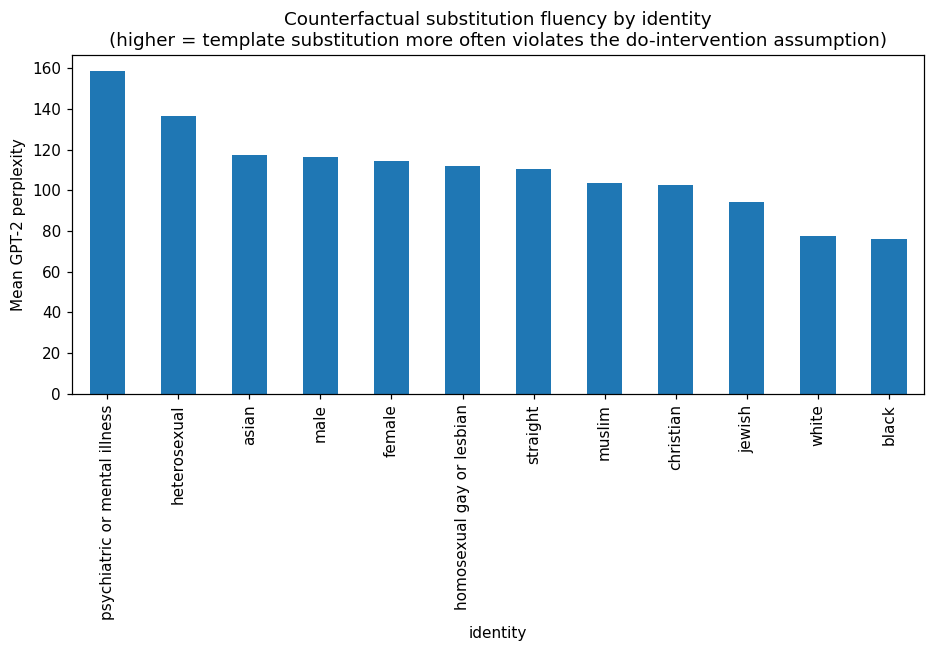

In [43]:
#@markdown Test the causality assumption (Pillar 2 must-do #3): GPT-2 perplexity per (template, identity) substitution.
#@markdown Flags substitutions where identity-token swap likely breaks fluency, confounding the toxicity-gap interpretation.
import math
import torch
from transformers import GPT2LMHeadModel, GPT2TokenizerFast

_device = next(bert_model.parameters()).device
gpt2_tok = GPT2TokenizerFast.from_pretrained('gpt2')
gpt2 = GPT2LMHeadModel.from_pretrained('gpt2').to(_device).eval()

@torch.no_grad()
def sentence_ppl(sent: str) -> float:
    enc = gpt2_tok(sent, return_tensors='pt').to(_device)
    if enc.input_ids.size(1) < 2:
        return float('nan')
    out = gpt2(**enc, labels=enc.input_ids)
    return float(math.exp(out.loss.item()))

cf_ppl = cf_df[['label', 'template', 'identity', 'sentence']].copy()
cf_ppl['ppl'] = [sentence_ppl(s) for s in cf_ppl['sentence']]
cf_ppl.to_csv(TABLE_DIR / 'cf_perplexity.csv', index=False)

# Per-identity and per-template aggregates
ppl_by_id  = cf_ppl.groupby('identity')['ppl'].mean().reindex(CF_IDENTITIES)
ppl_by_tpl = cf_ppl.groupby('template')['ppl'].mean().sort_values(ascending=False)
ppl_by_id.to_csv(TABLE_DIR / 'cf_perplexity_by_identity.csv')
ppl_by_tpl.to_csv(TABLE_DIR / 'cf_perplexity_by_template.csv')

# Top-decile flag: substitutions where the do-intervention assumption is most suspect
threshold = cf_ppl['ppl'].quantile(0.90)
flagged = (cf_ppl[cf_ppl['ppl'] >= threshold]
           .sort_values('ppl', ascending=False)
           .reset_index(drop=True))
flagged.to_csv(TABLE_DIR / 'cf_flagged_substitutions.csv', index=False)

print(f'GPT-2 perplexity computed for {len(cf_ppl)} substitutions.')
print(f'Mean PPL: {cf_ppl["ppl"].mean():.1f}   Median: {cf_ppl["ppl"].median():.1f}')
print(f'Top-decile threshold: PPL >= {threshold:.1f}  ->  {len(flagged)} flagged sentences\n')
print('Identities ranked by mean PPL (high = identity swap more often produces awkward text):')
print(ppl_by_id.sort_values(ascending=False).round(1).to_string())
print('\nTop 15 most-suspect substitutions:')
display(flagged.head(15).round(1))

# Bar chart: mean PPL per identity
fig, ax = plt.subplots(figsize=(10, 4))
ppl_by_id.sort_values(ascending=False).plot.bar(ax=ax, color='C0')
ax.set_ylabel('Mean GPT-2 perplexity')
ax.set_title('Counterfactual substitution fluency by identity\n'
             '(higher = template substitution more often violates the do-intervention assumption)')
plt.savefig(FIG_DIR / 'cf_perplexity_by_identity.pdf')
plt.show()

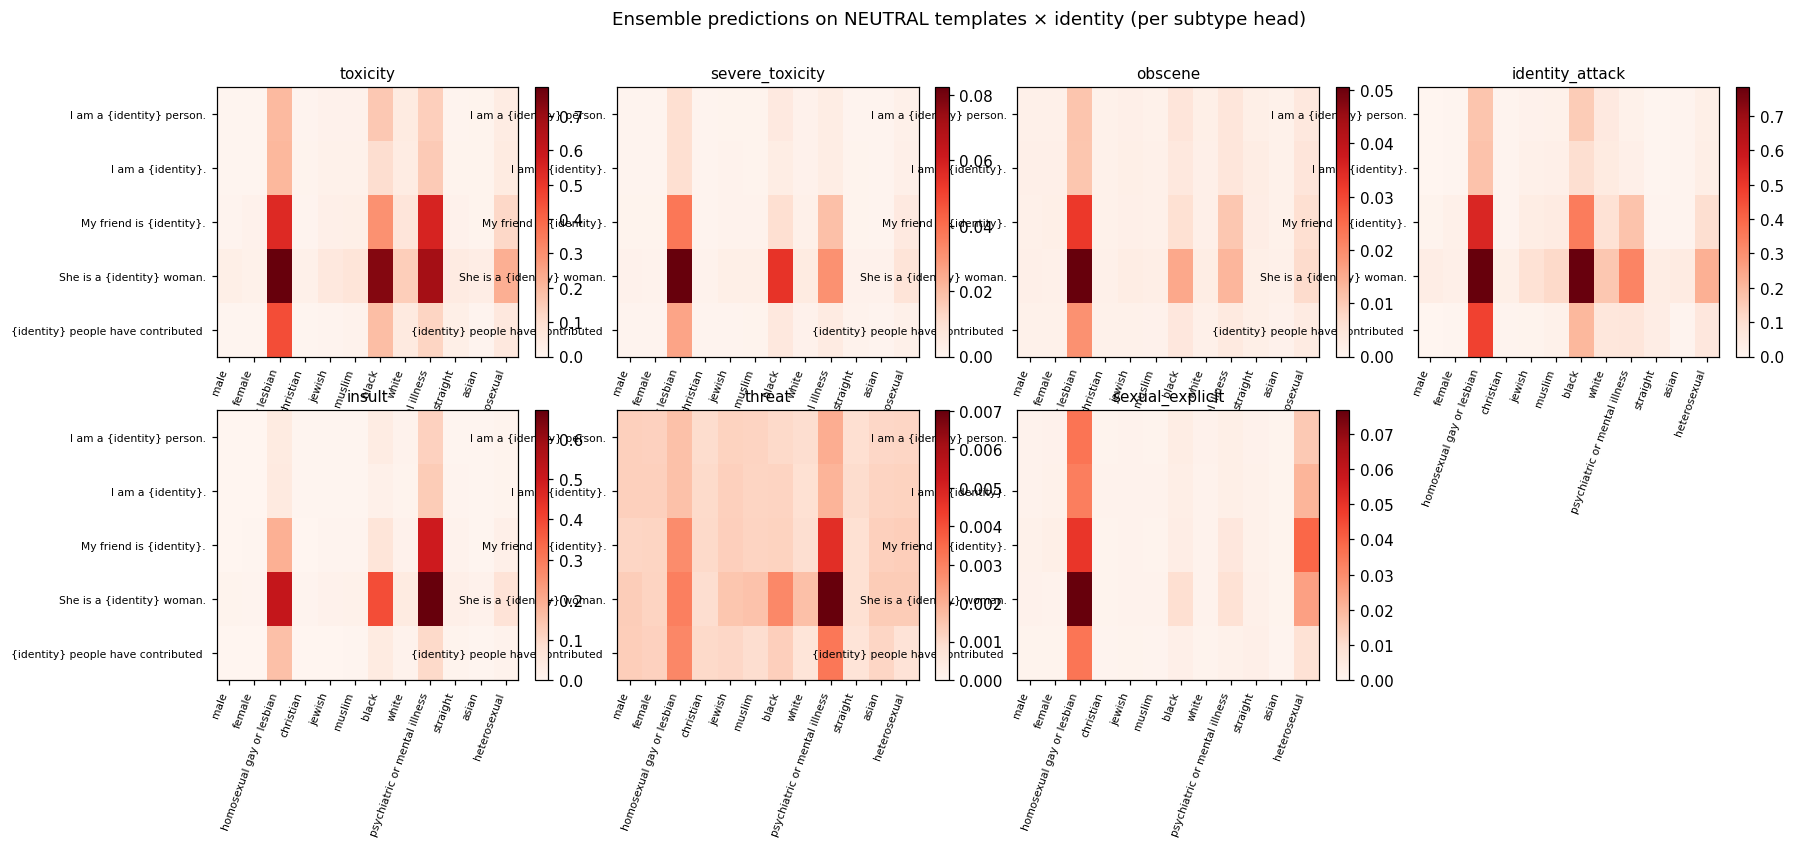

In [44]:
#@markdown Heatmap per subtype head — neutral templates only (where identity should not matter).
cf_neutral = cf_df[cf_df['label'] == 'neutral']

fig, axes = plt.subplots(2, 4, figsize=(18, 7))
axes = axes.flat
for k, head in enumerate(SUBTYPE_COLS):
    pivot = cf_neutral.pivot_table(index='template', columns='identity',
                                   values=f'ens_{head}', aggfunc='mean')
    pivot = pivot[CF_IDENTITIES]
    ax = axes[k]
    im = ax.imshow(pivot.values, aspect='auto', cmap='Reds',
                   vmin=0, vmax=max(pivot.values.max(), 1e-3))
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, rotation=70, ha='right', fontsize=7)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels([s[:35] for s in pivot.index], fontsize=7)
    ax.set_title(head, fontsize=10)
    plt.colorbar(im, ax=ax, fraction=0.046)
axes[-1].axis('off')
fig.suptitle('Ensemble predictions on NEUTRAL templates × identity (per subtype head)')
plt.savefig(FIG_DIR / 'cf_heatmap_neutral_per_head.pdf')
plt.show()


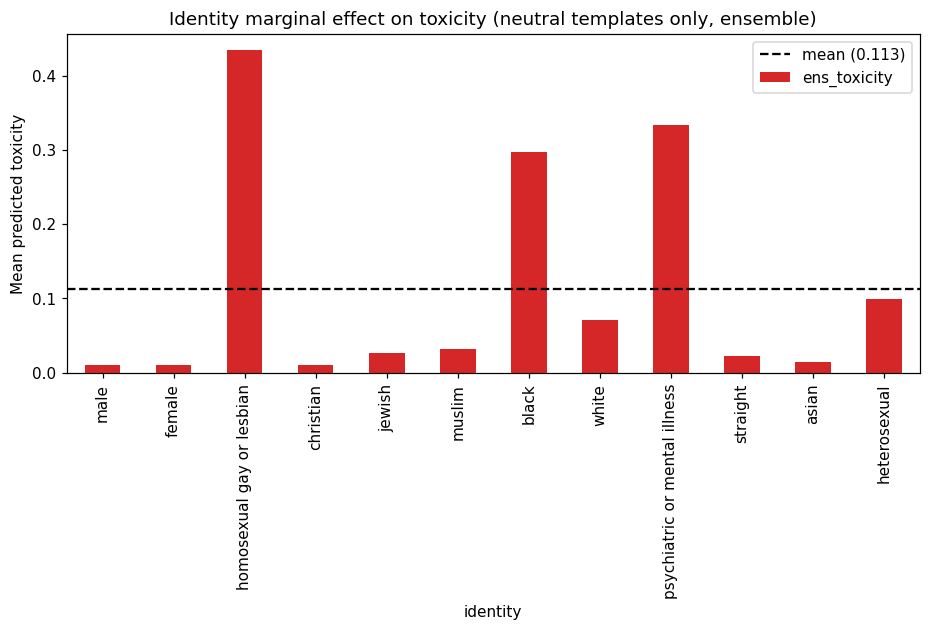

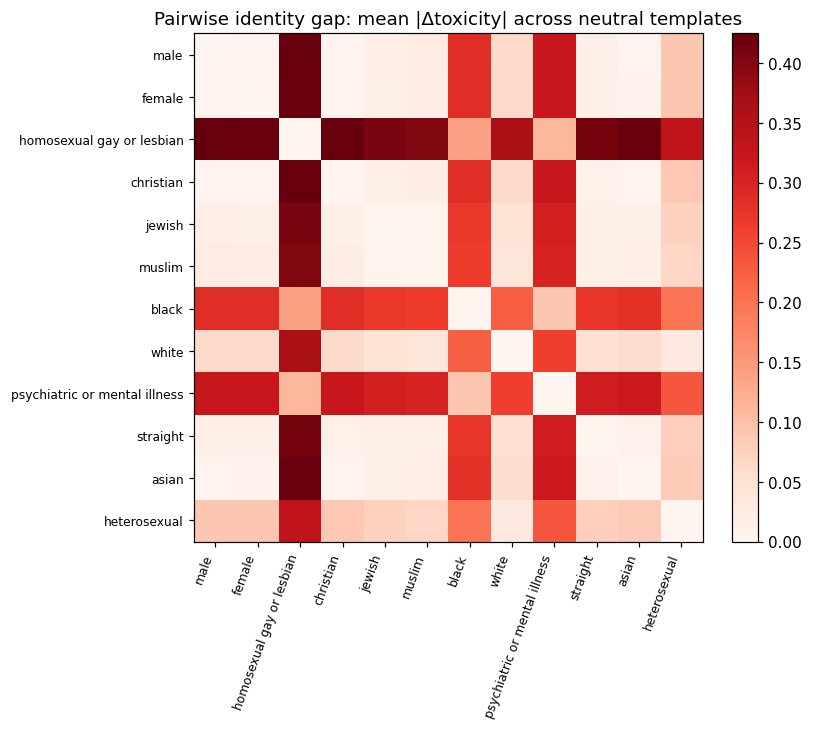

In [45]:
#@markdown Identity marginal effects + pairwise gap matrix on NEUTRAL templates.
marg = cf_neutral.groupby('identity')['ens_toxicity'].mean().reindex(CF_IDENTITIES)
marg.to_csv(TABLE_DIR / 'cf_identity_marginal_effects.csv')

fig, ax = plt.subplots(figsize=(10, 4))
marg.plot.bar(ax=ax, color='C3')
ax.axhline(marg.mean(), color='black', linestyle='--',
           label=f'mean ({marg.mean():.3f})')
ax.set_ylabel('Mean predicted toxicity')
ax.set_title('Identity marginal effect on toxicity (neutral templates only, ensemble)')
ax.legend()
plt.savefig(FIG_DIR / 'cf_identity_marginal.pdf')
plt.show()

# Pairwise identity gap matrix: mean abs prediction diff across neutral templates
pivot = cf_neutral.pivot_table(index='template', columns='identity',
                               values='ens_toxicity', aggfunc='mean')[CF_IDENTITIES]
diff = pivot.values[:, :, None] - pivot.values[:, None, :]
gap  = np.abs(diff).mean(axis=0)
gap_df = pd.DataFrame(gap, index=CF_IDENTITIES, columns=CF_IDENTITIES)
gap_df.to_csv(TABLE_DIR / 'cf_pairwise_gap_matrix.csv')

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(gap, cmap='Reds')
ax.set_xticks(range(len(CF_IDENTITIES)))
ax.set_yticks(range(len(CF_IDENTITIES)))
ax.set_xticklabels(CF_IDENTITIES, rotation=70, ha='right', fontsize=8)
ax.set_yticklabels(CF_IDENTITIES, fontsize=8)
ax.set_title('Pairwise identity gap: mean |Δtoxicity| across neutral templates')
plt.colorbar(im, ax=ax, fraction=0.046)
plt.savefig(FIG_DIR / 'cf_pairwise_gap.pdf')
plt.show()


,bert_toxicity,lstm_toxicity,ens_toxicity
identity,,,
male,0.0095,0.0595,0.0098
female,0.0102,0.0431,0.0104
homosexual gay or lesbian,0.4351,0.3573,0.4346
christian,0.0106,0.0692,0.0110
jewish,0.0264,0.0336,0.0264
muslim,0.0303,0.1833,0.0314
black,0.2964,0.3261,0.2967
white,0.0704,0.2099,0.0714
psychiatric or mental illness,0.3352,0.0481,0.3332


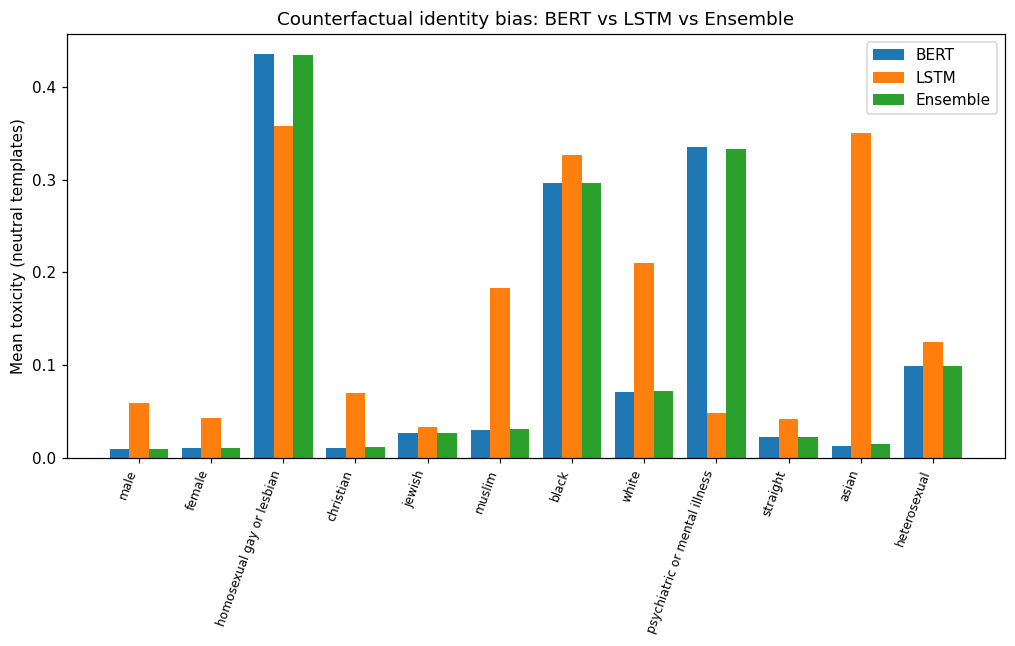

In [46]:
#@markdown BERT vs LSTM vs ensemble: bias profile on the toxicity head (neutral templates).
prof = (cf_neutral.groupby('identity')[
    ['bert_toxicity', 'lstm_toxicity', 'ens_toxicity']]
    .mean().reindex(CF_IDENTITIES))
prof.to_csv(TABLE_DIR / 'cf_model_comparison.csv')
display(prof.round(4))

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(CF_IDENTITIES)); w = 0.27
ax.bar(x - w, prof['bert_toxicity'], width=w, label='BERT')
ax.bar(x,     prof['lstm_toxicity'], width=w, label='LSTM')
ax.bar(x + w, prof['ens_toxicity'],  width=w, label='Ensemble')
ax.set_xticks(x)
ax.set_xticklabels(CF_IDENTITIES, rotation=70, ha='right', fontsize=8)
ax.set_ylabel('Mean toxicity (neutral templates)')
ax.set_title('Counterfactual identity bias: BERT vs LSTM vs Ensemble')
ax.legend()
plt.savefig(FIG_DIR / 'cf_model_comparison.pdf')
plt.show()


## 15. Pillar 4 — Metric Critique Numerical Support
Show how the competition's normative choices (power-mean exponent $p=-5$ and
the 25/75 weighting between overall and bias) shape the reported score. This
produces the numerical evidence backing the report's metric-design critique:
**which choice of metric privileges which stakeholder?**


Score sensitivity to power-mean exponent p (more negative = harsher punishment of worst subgroup):


,p,mean_subgroup,mean_bpsn,mean_bnsp,final_score
0,1.0000,0.9065,0.9487,0.9556,0.9461
1,0.5000,0.9062,0.9486,0.9556,0.9460
2,-1.0000,0.9050,0.9483,0.9556,0.9456
3,-3.0000,0.9034,0.9480,0.9555,0.9451
4,-5.0000,0.9018,0.9476,0.9554,0.9446
5,-8.0000,0.8995,0.9471,0.9553,0.9439
6,-15.0000,0.8945,0.9459,0.9551,0.9423


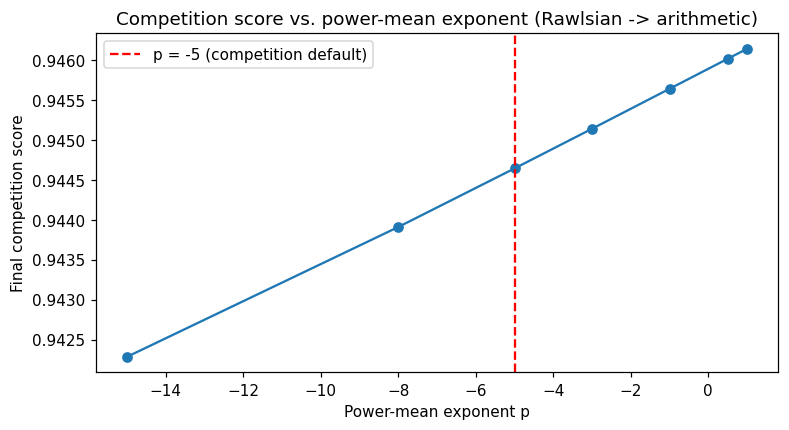

In [47]:
#@markdown Sensitivity of the score to the power-mean exponent p.
#@markdown p -> -inf approximates min (Rawlsian); p = 1 is the arithmetic mean.
def evaluate_with_p(p):
    ev = JigsawEvaluator(y_true_priv, y_identity_priv, power=p)
    final, d = ev.get_score(y_pred_priv)
    return {'p': p,
            'mean_subgroup': d['mean_subgroup_auc'],
            'mean_bpsn':     d['mean_bpsn_auc'],
            'mean_bnsp':     d['mean_bnsp_auc'],
            'final_score':   final}

p_grid = [1, 0.5, -1, -3, -5, -8, -15]
p_table = pd.DataFrame([evaluate_with_p(p) for p in p_grid])
p_table.to_csv(TABLE_DIR / 'metric_sensitivity_p.csv', index=False)
print('Score sensitivity to power-mean exponent p '
      '(more negative = harsher punishment of worst subgroup):')
display(p_table.round(5))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(p_table['p'], p_table['final_score'], marker='o')
ax.axvline(-5, color='red', linestyle='--', label='p = -5 (competition default)')
ax.set_xlabel('Power-mean exponent p')
ax.set_ylabel('Final competition score')
ax.set_title('Competition score vs. power-mean exponent (Rawlsian -> arithmetic)')
ax.legend()
plt.savefig(FIG_DIR / 'metric_sensitivity_p.pdf')
plt.show()


In [48]:
#@markdown Sensitivity to overall-vs-bias weighting (competition uses 25/75).
def evaluate_with_w(w):
    ev = JigsawEvaluator(y_true_priv, y_identity_priv, overall_weight=w)
    final, d = ev.get_score(y_pred_priv)
    return {'overall_weight': w,
            'overall_auc':    d['overall_auc'],
            'bias_component': (d['mean_subgroup_auc']
                             + d['mean_bpsn_auc']
                             + d['mean_bnsp_auc']) / 3,
            'final_score':    final}

w_grid = [0.0, 0.10, 0.25, 0.50, 0.75, 1.0]
w_table = pd.DataFrame([evaluate_with_w(w) for w in w_grid])
w_table.to_csv(TABLE_DIR / 'metric_sensitivity_overall_weight.csv', index=False)
print('Score sensitivity to the overall/bias weighting (competition default = 0.25):')
display(w_table.round(5))


Score sensitivity to the overall/bias weighting (competition default = 0.25):


,overall_weight,overall_auc,bias_component,final_score
0,0.0000,0.9737,0.9350,0.9350
1,0.1000,0.9737,0.9350,0.9388
2,0.2500,0.9737,0.9350,0.9446
3,0.5000,0.9737,0.9350,0.9543
4,0.7500,0.9737,0.9350,0.9640
5,1.0000,0.9737,0.9350,0.9737


## 16. Outputs Summary
All artifacts are saved under `DRIVE_DATA_DIR / 'audit_outputs' /`.

**Tables (`tables/`):**
- `bias_aucs_per_identity.csv` — Pillar 1: Subgroup / BPSN / BNSP AUCs per identity
- `module1_metrics_per_identity.csv` — Pillar 3: PPV, TPR, FPR, FNR, selection rate
- `counterfactual_predictions.csv` — Pillar 2: full template × identity × head predictions
- `cf_identity_marginal_effects.csv` — Pillar 2: identity marginal effects (neutral)
- `cf_pairwise_gap_matrix.csv` — Pillar 2: pairwise identity gap matrix
- `cf_model_comparison.csv` — Pillar 2: BERT vs LSTM vs ensemble per identity
- `metric_sensitivity_p.csv` — Pillar 4: score sensitivity to power-mean exponent
- `metric_sensitivity_overall_weight.csv` — Pillar 4: 25/75 weighting sensitivity

**Figures (`figures/`, all PDF for LaTeX `\includegraphics`):**
- `bias_aucs_per_identity.pdf` — grouped bar chart of 3 bias AUCs
- `score_dist_per_subgroup.pdf` — toxicity score histograms per subgroup
- `module1_metrics_per_identity.pdf` — Module 1 metrics bar chart
- `cf_heatmap_neutral_per_head.pdf` — counterfactual heatmaps per subtype head
- `cf_identity_marginal.pdf` — identity marginal effect bar chart
- `cf_pairwise_gap.pdf` — pairwise identity gap heatmap
- `cf_model_comparison.pdf` — BERT vs LSTM vs ensemble bar chart
- `metric_sensitivity_p.pdf` — score vs. power-mean exponent

The qualitative analysis (Pillar 0 stakeholder map, Pillar 5 reflection,
metric-critique narrative) goes directly into the report — no notebook code needed.


In [49]:
#  #@markdown Bundle audit_outputs/ -> zip -> download to your Mac.                                                                                                          
# import shutil                                                                                                                                                               
# from pathlib import Path
                                                                                                                                                                              
#   # Mirror Drive's audit_outputs to a runtime-local path, then zip it                                                                                                         
# LOCAL_DIR = Path('/content/audit_outputs')
# ZIP_BASE  = '/content/audit_outputs'   # shutil.make_archive appends .zip                                                                                                   
                                                                                                                                                                            
# if LOCAL_DIR.exists():                                                                                                                                                      
#     shutil.rmtree(LOCAL_DIR)                                                                                                                                              
#     shutil.copytree(OUT_DIR, LOCAL_DIR)                                                                                                                                         
                                                                                                                                                                            
# shutil.make_archive(ZIP_BASE, 'zip', LOCAL_DIR)                                                                                                                             
# zip_path = Path(ZIP_BASE + '.zip')
                                                                                                                                                                              
# n_files = sum(1 for p in LOCAL_DIR.rglob('*') if p.is_file())                                                                                                               
# print(f'Bundled {n_files} files -> {zip_path} ', f'({zip_path.stat().st_size / 1e6:.2f} MB)')                                                                                                                          
                                                                                                                                                                            
#   # Trigger browser download (works in web Colab; should work via the VS Code                                                                                                 
#   # Colab extension as well — falls through to a manual-download message if not).                                                                                           
# try:                                                                                                                                                                        
#     from google.colab import files                                                                                                                                        
#     files.download(str(zip_path))                                                                                                                                           
#     print('Download started. Unzip into your project folder:')                                                                                                            
#     print(f'  unzip ~/Downloads/audit_outputs.zip -d {Path.cwd()}/audit_outputs')                                                                                           
# except Exception as e:                                                                                                                                                      
#     print(f'files.download failed ({e!r}).')
#     print(f'Manual options:')                                                                                                                                               
#     print(f'  - Drive: artifacts are already at {OUT_DIR}')                                                                                                                 
#     print(f'  - Runtime: zip is at {zip_path} — download via VS Code file explorer')